# Percobaan Pengaruh Banyak Filter per Layer Konvolusi

#### Import Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

Seeding

In [2]:
import random
import os

# Atur seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

#### Load Dataset

In [3]:
# Load dataset CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Split train -> 40k train, 10k validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# Normalisasi data (0-1)
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

Train shape: (40000, 32, 32, 3), Validation shape: (10000, 32, 32, 3), Test shape: (10000, 32, 32, 3)


## Model 1: [16, 32, 64] Filter

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.2915 - loss: 1.9201 - val_accuracy: 0.4634 - val_loss: 1.4612
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4874 - loss: 1.4181 - val_accuracy: 0.5408 - val_loss: 1.2907
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.5418 - loss: 1.2853 - val_accuracy: 0.5786 - val_loss: 1.1985
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5769 - loss: 1.1950 - val_accuracy: 0.6036 - val_loss: 1.1399
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6064 - loss: 1.1184 - val_accuracy: 0.6160 - val_loss: 1.0952
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6309 - loss: 1.0545 - val_accuracy: 0.6238 - val_loss: 1.0650
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6490 - loss: 1.0051 - val_accuracy: 0.6315 - val_loss: 1.0540
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6636 - loss: 0.9631 - v

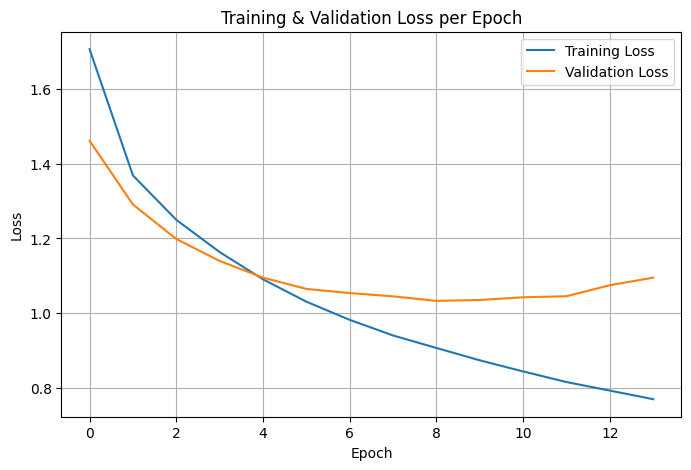

In [4]:
# Make model with [16, 32] Filter
model1 = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model1
model1.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model1
history = model1.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model1.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 2: [32, 64, 128] Filter

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3052 - loss: 1.8562 - val_accuracy: 0.5242 - val_loss: 1.3182
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5258 - loss: 1.3237 - val_accuracy: 0.5942 - val_loss: 1.1582
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5971 - loss: 1.1499 - val_accuracy: 0.6225 - val_loss: 1.0804
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6413 - loss: 1.0275 - val_accuracy: 0.6402 - val_loss: 1.0426
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6769 - loss: 0.9327 - val_accuracy: 0.6462 - val_loss: 1.0308
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7076 - loss: 0.8541 - val_accuracy: 0.6684 - val_loss: 0.9818
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7306 - loss: 0.7924 - val_accuracy: 0.6661 - val_loss: 1.0037
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7432 - loss: 0.7492 - val_acc

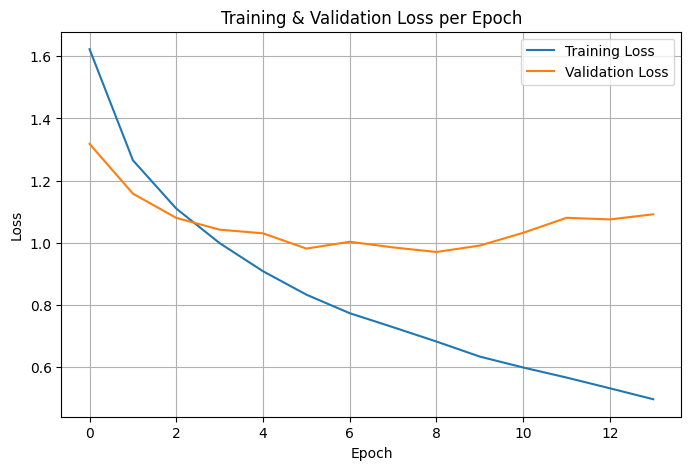

In [5]:
# Make model with [32, 64] Filter
model2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model2
model2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model2
history = model2.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model2.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 3: [64, 128, 256] Filter

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.3111 - loss: 1.8488 - val_accuracy: 0.5527 - val_loss: 1.2707
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.5572 - loss: 1.2503 - val_accuracy: 0.6359 - val_loss: 1.0694
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.6385 - loss: 1.0332 - val_accuracy: 0.6668 - val_loss: 0.9740
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.6876 - loss: 0.8938 - val_accuracy: 0.6896 - val_loss: 0.9223
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7300 - loss: 0.7829 - val_accuracy: 0.6980 - val_loss: 0.9166
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7625 - loss: 0.6916 - val_accuracy: 0.6981 - val_loss: 0.9180
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7902 - loss: 0.6120 - val_accuracy: 0.6956 - val_loss: 0.9534
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8144 - loss: 0.5400 - 

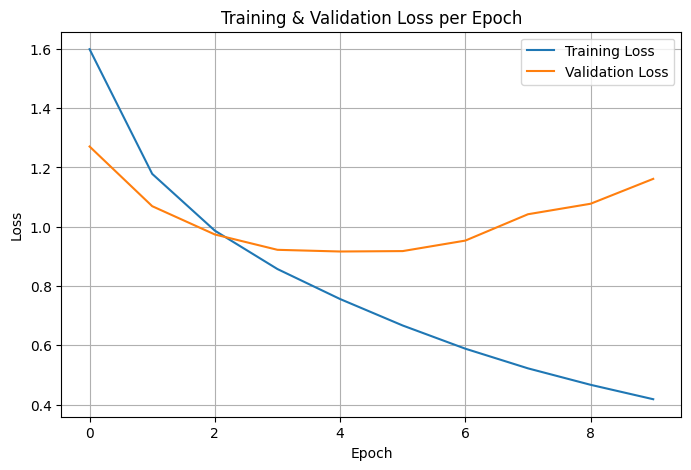

In [6]:
# Make model with [64, 128] Filter
model3 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model3
model3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model3
history = model3.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model3.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()